# 05_backtest.ipynb — 回测执行与结果分析

**数据口径**
- 基准：中证500全收益指数 NAV（`index_quote.parquet` 的 `nav` 列，起点=1.0）
- 执行价：T+1 开盘价（`open_adj`），加滑点 8 bps
- 成本：印花税（卖出单边，2023-08-28 前后分段）+ 双边佣金 2.5 bps + 双边滑点 8 bps

**模式切换**
- `USE_MOCK_DATA = True`：合成等权权重（nb04 输出不存在时使用）
- `USE_MOCK_DATA = False`：加载 `portfolio_weights_*.parquet`（nb04 运行后切换）

**时间纪律**：本 notebook 仅使用验证集（2022）。测试集（2023-2025）仅在 `[TEST_SET_RUN_N]` commit 时运行。

In [1]:
# ── Cell 1：全局开关 + Imports ────────────────────────────────────────────────
USE_MOCK_DATA = False   # 切换入口：True = 合成权重；False = nb04 真实权重

import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src import config as cfg
from src.backtest.engine import BacktestConfig, BacktestResult, run_backtest
from src.backtest.metrics import summarize

# ── 中文字体（Windows）──────────────────────────────────────────────────────────
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False   # 负号正常显示
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# ── 时间区间（验证集，不触碰测试集）────────────────────────────────────────────
BACKTEST_START = cfg.VALID_START   # 2022-01-01
BACKTEST_END   = cfg.VALID_END     # 2022-12-31

print(f"USE_MOCK_DATA = {USE_MOCK_DATA}")
print(f"回测区间：{BACKTEST_START.date()} → {BACKTEST_END.date()}")

USE_MOCK_DATA = False
回测区间：2022-01-01 → 2022-12-31


In [2]:
# ── Cell 2：权重加载（Mock 模式 / 真实模式）──────────────────────────────────────

if USE_MOCK_DATA:
    # E19 保证：mock 模式不读取 portfolio_weights_*.parquet（文件可能不存在）
    from src.data.loader import get_rebalance_dates, load_universe

    rebal_dates = get_rebalance_dates(start=BACKTEST_START, end=BACKTEST_END)
    rng = np.random.default_rng(cfg.RANDOM_SEED)

    w1_dict, w2_dict = {}, {}
    for d in rebal_dates:
        snap  = load_universe(d)
        codes = snap.index.tolist()   # 500 只成分股
        n     = len(codes)

        # V1 Baseline：等权
        w1_dict[d] = pd.Series(1.0 / n, index=codes)

        # V2 模拟优化权重：在等权基础上加随机扰动，保证非负且归一
        noise = rng.normal(0, 0.002, n)
        w2    = 1.0 / n + noise
        w2    = np.maximum(w2, 0.0)
        w2   /= w2.sum()
        w2_dict[d] = pd.Series(w2, index=codes)

    weights_v1 = pd.DataFrame(w1_dict).T
    weights_v2 = pd.DataFrame(w2_dict).T
    print(f"[MOCK] 生成 {len(rebal_dates)} 期合成权重，权重矩阵 shape：{weights_v1.shape}")

else:
    # 真实模式：加载 nb04 的优化权重输出
    weights_v1 = pd.read_parquet(cfg.DATA_PROC / "portfolio_weights_baseline.parquet")
    weights_v2 = pd.read_parquet(cfg.DATA_PROC / "portfolio_weights_optimized.parquet")
    print(f"[REAL] 加载真实权重 V1 shape={weights_v1.shape}, V2 shape={weights_v2.shape}")

# 权重健全性检查
w1_sum = weights_v1.sum(axis=1)
w2_sum = weights_v2.sum(axis=1)
print(f"V1 权重和 min={w1_sum.min():.6f}  max={w1_sum.max():.6f}")
print(f"V2 权重和 min={w2_sum.min():.6f}  max={w2_sum.max():.6f}")

[REAL] 加载真实权重 V1 shape=(84, 1069), V2 shape=(84, 1069)
V1 权重和 min=1.000000  max=1.000000
V2 权重和 min=1.000000  max=1.000000


In [3]:
# ── Cell 3：运行回测 ──────────────────────────────────────────────────────────
import logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")

config = BacktestConfig(initial_value=1.0)

print("运行 V1 Baseline 回测...")
result_v1 = run_backtest(weights_v1, BACKTEST_START, BACKTEST_END, config)

print("\n运行 V2 优化权重回测...")
result_v2 = run_backtest(weights_v2, BACKTEST_START, BACKTEST_END, config)

# V0：基准（全收益指数），从两个 result 中的 benchmark_nav 提取
# E20 保证：三条曲线用 inner 对齐，起点相同
bench_nav = result_v1.benchmark_nav   # V1/V2 基准相同（同一 index_quote 来源）

print("\n── 回测完成 ──")
print(f"NAV 长度：{len(result_v1.nav)} 个交易日")
print(f"调仓记录：V1={len(result_v1.trade_log)} 次  V2={len(result_v2.trade_log)} 次")

INFO src.backtest.engine: 回测区间 [2022-01-01, 2022-12-31]


INFO src.backtest.engine: 执行映射：84 个调仓日 → 12 个执行日


运行 V1 Baseline 回测...


INFO src.backtest.engine: 回测完成 | 年化超额 -4.05% | IR -0.702 | 超额最大回撤 -9.48%


INFO src.backtest.engine: 回测区间 [2022-01-01, 2022-12-31]


INFO src.backtest.engine: 执行映射：84 个调仓日 → 12 个执行日



运行 V2 优化权重回测...


INFO src.backtest.engine: 回测完成 | 年化超额 1.47% | IR 0.340 | 超额最大回撤 -4.66%



── 回测完成 ──
NAV 长度：242 个交易日
调仓记录：V1=12 次  V2=12 次


In [4]:
# ── Cell 4：自检 ──────────────────────────────────────────────────────────────
errors = []

def check(cond: bool, msg: str):
    if cond:
        print(f"  [PASS] {msg}")
    else:
        print(f"  [FAIL] {msg}")
        errors.append(msg)

print("=== 自检报告 ===")

# A. NAV 正确性
# nav.iloc[0] 是第一个交易日（2022-01-04）收盘估值：
#   当天以开盘价建仓、收盘价估值，自然反映当日价差 + 建仓成本，不等于 1.0。
#   用 ±2% 容差确认量级合理，而非要求精确为 1.0。
check(abs(result_v1.nav.iloc[0] - 1.0) < 0.02,  "V1 NAV 起点≈1.0（±2%，允许首日建仓成本+价差）")
check(abs(result_v2.nav.iloc[0] - 1.0) < 0.02,  "V2 NAV 起点≈1.0（±2%，允许首日建仓成本+价差）")
check(abs(bench_nav.iloc[0] - 1.0) < 1e-9,       "基准 NAV 起点 = 1.0")
check(result_v1.nav.isna().sum() == 0,            "V1 NAV 无 NaN")
check(result_v2.nav.isna().sum() == 0,            "V2 NAV 无 NaN")

# B. E20：三条曲线起点日期一致
check(
    result_v1.nav.index[0] == result_v2.nav.index[0] == bench_nav.index[0],
    "E20：三条曲线起点日期相同"
)

# C. 成本
check(result_v1.trade_log["cost"].sum() > 0,       "V1 trade_log 有非零 cost")
check(result_v2.trade_log["cost"].sum() > 0,       "V2 trade_log 有非零 cost")
check(result_v1.trade_log.iloc[0]["sell_value"] == 0.0, "首期 sell_value=0（从空仓建仓）")

# D. 指标规范
check(result_v1.metrics["max_drawdown"] <= 0.0,    "V1 max_drawdown ≤ 0（返回负数）")
check(result_v2.metrics["max_drawdown"] <= 0.0,    "V2 max_drawdown ≤ 0（返回负数）")
check(result_v1.metrics["tracking_error"] >= 0.0, "V1 TE ≥ 0")
check(0.0 <= result_v1.metrics["monthly_win_rate"] <= 1.0, "V1 月胜率在 [0,1]")

# E. 测试集纪律
check(result_v1.nav.index.max() <= cfg.VALID_END,  "NAV 最晚日期 ≤ 验证集结束（未触碰测试集）")

# E19：mock 模式不应读取真实权重文件
if USE_MOCK_DATA:
    baseline_path = cfg.DATA_PROC / "portfolio_weights_baseline.parquet"
    check(not baseline_path.exists(), "E19：MOCK 模式未读取 portfolio_weights_baseline.parquet")
    print("  [NOTE] E19：若 baseline.parquet 已存在，MOCK 模式仍未读取它（已通过 USE_MOCK_DATA 隔离）")

print()
if not errors:
    print("所有检查项通过 ✓")
else:
    print(f"发现 {len(errors)} 项问题：")
    for e in errors:
        print(f"  - {e}")

=== 自检报告 ===
  [PASS] V1 NAV 起点≈1.0（±2%，允许首日建仓成本+价差）
  [PASS] V2 NAV 起点≈1.0（±2%，允许首日建仓成本+价差）
  [PASS] 基准 NAV 起点 = 1.0
  [PASS] V1 NAV 无 NaN
  [PASS] V2 NAV 无 NaN
  [PASS] E20：三条曲线起点日期相同
  [PASS] V1 trade_log 有非零 cost
  [PASS] V2 trade_log 有非零 cost
  [PASS] 首期 sell_value=0（从空仓建仓）
  [PASS] V1 max_drawdown ≤ 0（返回负数）
  [PASS] V2 max_drawdown ≤ 0（返回负数）
  [PASS] V1 TE ≥ 0
  [PASS] V1 月胜率在 [0,1]
  [PASS] NAV 最晚日期 ≤ 验证集结束（未触碰测试集）

所有检查项通过 ✓


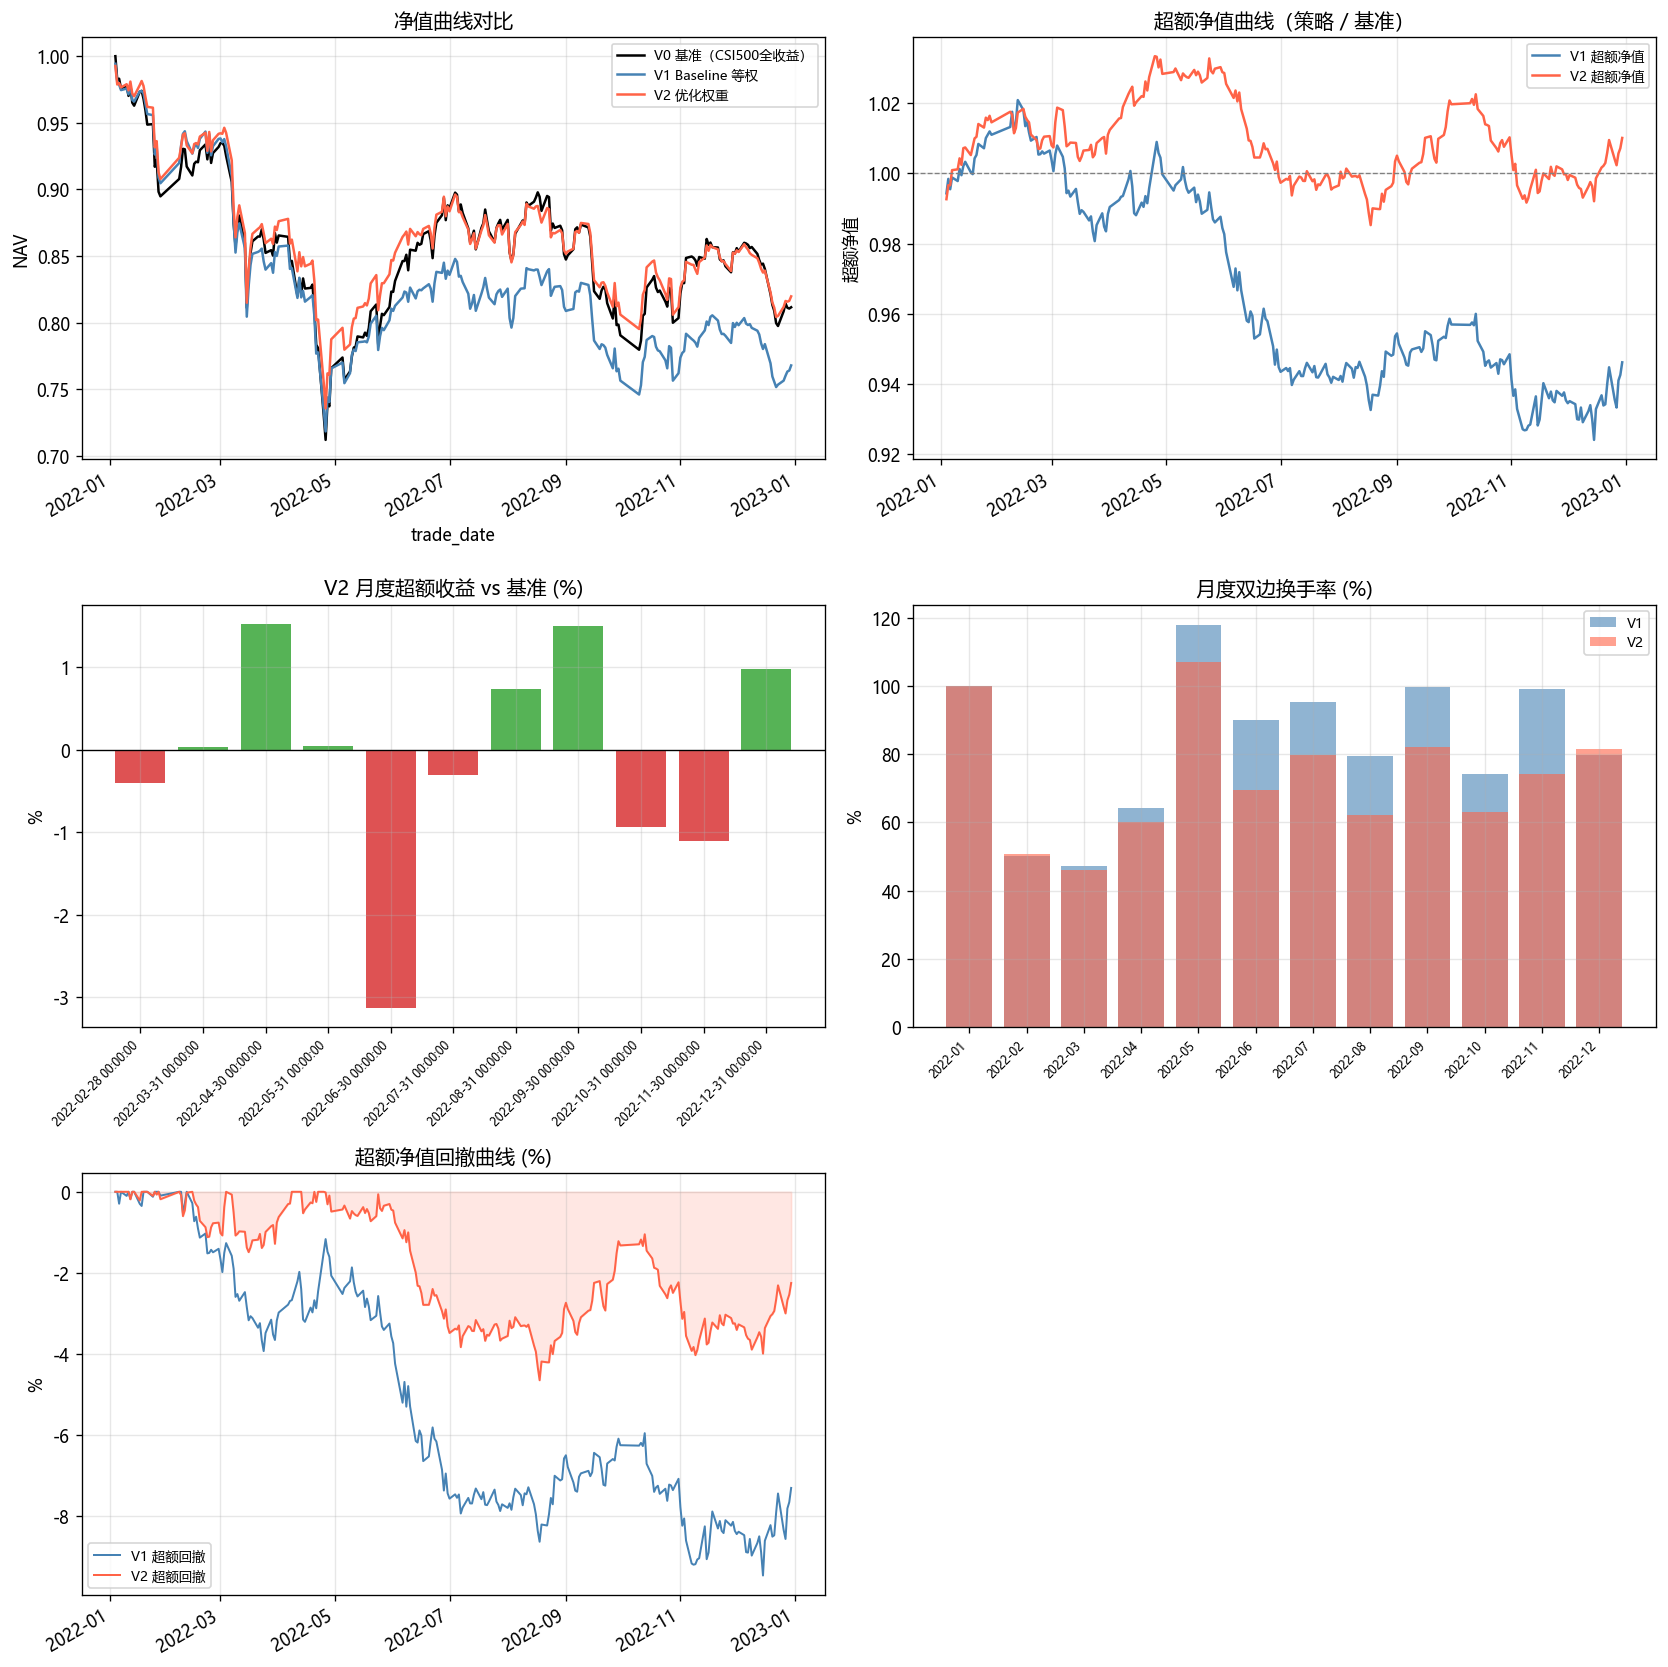

图表已保存至 data/processed/backtest_plots.png


In [5]:
# ── Cell 5：可视化（5 张图）──────────────────────────────────────────────────

def _pct(x): return x * 100

# 月度数据辅助
def monthly_excess(nav: pd.Series, bench: pd.Series) -> pd.Series:
    """月度超额收益（策略月收益 - 基准月收益）。"""
    m_nav   = nav.resample("ME").last().pct_change().dropna()
    m_bench = bench.resample("ME").last().pct_change().dropna()
    m_nav, m_bench = m_nav.align(m_bench, join="inner")
    return m_nav - m_bench

def monthly_turnover(result: BacktestResult) -> pd.Series:
    """月度双边换手率（(buy+sell) / portfolio_value_before）。"""
    if result.trade_log.empty:
        return pd.Series(dtype=float)
    tl = result.trade_log.copy()
    tl["month"] = pd.to_datetime(tl["exec_date"]).dt.to_period("M")
    tl["turnover"] = (
        (tl["buy_value"] + tl["sell_value"]) / tl["portfolio_value_before"]
    )
    return tl.groupby("month")["turnover"].sum()

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
ax1, ax2, ax3, ax4, ax5, ax6 = axes.flat

# 图 1：净值曲线对比
bench_nav.plot(ax=ax1, label="V0 基准（CSI500全收益）", color="black",  lw=1.5)
result_v1.nav.plot(ax=ax1, label="V1 Baseline 等权",     color="steelblue", lw=1.5)
result_v2.nav.plot(ax=ax1, label="V2 优化权重",           color="tomato",    lw=1.5)
ax1.set_title("净值曲线对比")
ax1.set_ylabel("NAV")
ax1.legend(fontsize=8)

# 图 2：超额净值曲线
result_v1.excess_nav.plot(ax=ax2, label="V1 超额净值", color="steelblue", lw=1.5)
result_v2.excess_nav.plot(ax=ax2, label="V2 超额净值", color="tomato",    lw=1.5)
ax2.axhline(1.0, color="gray", lw=0.8, ls="--")
ax2.set_title("超额净值曲线（策略 / 基准）")
ax2.set_ylabel("超额净值")
ax2.legend(fontsize=8)

# 图 3：V2 月度超额收益柱状图
exc_v2 = monthly_excess(result_v2.nav, bench_nav)
colors  = ["#2ca02c" if v > 0 else "#d62728" for v in exc_v2.values]
ax3.bar(range(len(exc_v2)), _pct(exc_v2.values), color=colors, alpha=0.8)
ax3.axhline(0, color="black", lw=0.8)
ax3.set_xticks(range(len(exc_v2)))
ax3.set_xticklabels([str(p) for p in exc_v2.index], rotation=45, ha="right", fontsize=7)
ax3.set_title("V2 月度超额收益 vs 基准 (%)")
ax3.set_ylabel("%")

# 图 4：月度双边换手率
to_v1 = monthly_turnover(result_v1)
to_v2 = monthly_turnover(result_v2)
idx_str_v1 = [str(p) for p in to_v1.index]
idx_str_v2 = [str(p) for p in to_v2.index]
ax4.bar(range(len(to_v1)), _pct(to_v1.values), alpha=0.6, label="V1", color="steelblue")
ax4.bar(range(len(to_v2)), _pct(to_v2.values), alpha=0.6, label="V2", color="tomato")
ax4.set_xticks(range(len(to_v1)))
ax4.set_xticklabels(idx_str_v1, rotation=45, ha="right", fontsize=7)
ax4.set_title("月度双边换手率 (%)")
ax4.set_ylabel("%")
ax4.legend(fontsize=8)

# 图 5：超额回撤曲线
from src.backtest.metrics import excess_nav as calc_excess_nav, max_drawdown
exc_v1_series = result_v1.excess_nav
exc_v2_series = result_v2.excess_nav
dd_v1 = (exc_v1_series / exc_v1_series.cummax() - 1) * 100
dd_v2 = (exc_v2_series / exc_v2_series.cummax() - 1) * 100
dd_v1.plot(ax=ax5, label="V1 超额回撤", color="steelblue", lw=1.2)
dd_v2.plot(ax=ax5, label="V2 超额回撤", color="tomato",    lw=1.2)
ax5.fill_between(dd_v2.index, dd_v2.values, 0, alpha=0.15, color="tomato")
ax5.set_title("超额净值回撤曲线 (%)")
ax5.set_ylabel("%")
ax5.legend(fontsize=8)

# 图 6 空白留给 metrics 表格（用 text 展示）
ax6.axis("off")

plt.tight_layout()
plt.savefig("../data/processed/backtest_plots.png", dpi=120, bbox_inches="tight")
plt.show()
print("图表已保存至 data/processed/backtest_plots.png")

In [6]:
# ── Cell 6：指标汇总表 ────────────────────────────────────────────────────────

def fmt_metrics(metrics: dict) -> pd.Series:
    """将 metrics dict 格式化为可读 Series（百分比 + 小数）。
    E21：max_drawdown 取绝对值展示（原始为负数）。
    """
    return pd.Series({
        "年化收益率 (%)": f"{metrics['annualized_return']*100:.2f}",
        "年化波动率 (%)": f"{metrics['annualized_vol']*100:.2f}",
        "夏普比率":      f"{metrics['sharpe']:.3f}",
        "最大回撤 (%)": f"{abs(metrics['max_drawdown'])*100:.2f}",   # E21：取绝对值
        "卡玛比率":      f"{metrics['calmar_ratio']:.3f}",
        "基准年化 (%)": f"{metrics['benchmark_return']*100:.2f}",
        "年化超额 (%)": f"{metrics['excess_return']*100:.2f}",
        "跟踪误差 (%)": f"{metrics['tracking_error']*100:.2f}",
        "信息比率 IR":  f"{metrics['information_ratio']:.3f}",
        "超额最大回撤 (%)": f"{abs(metrics['excess_max_drawdown'])*100:.2f}",  # E21
        "月胜率 (%)": f"{metrics['monthly_win_rate']*100:.1f}",
    })

metrics_table = pd.DataFrame({
    "V1 Baseline": fmt_metrics(result_v1.metrics),
    "V2 优化权重": fmt_metrics(result_v2.metrics),
})

print("=== 绩效指标汇总 ===")
print(f"回测区间：{result_v1.nav.index[0].date()} → {result_v1.nav.index[-1].date()}")
print(f"注：首期换手率约100%（空仓建仓），属正常情况。")
print()
print(metrics_table.to_string())

=== 绩效指标汇总 ===
回测区间：2022-01-04 → 2022-12-30
注：首期换手率约100%（空仓建仓），属正常情况。

           V1 Baseline V2 优化权重
年化收益率 (%)       -23.60  -18.08
年化波动率 (%)        20.22   20.42
夏普比率            -1.334  -0.975
最大回撤 (%)         27.76   25.90
卡玛比率            -0.850  -0.698
基准年化 (%)        -19.55  -19.55
年化超额 (%)         -4.05    1.47
跟踪误差 (%)          5.77    4.33
信息比率 IR         -0.702   0.340
超额最大回撤 (%)        9.48    4.66
月胜率 (%)           36.4    54.5


In [7]:
# ── Cell 7：落盘 ──────────────────────────────────────────────────────────────
from pathlib import Path

out_dir = cfg.DATA_PROC
out_dir.mkdir(parents=True, exist_ok=True)

# 对齐三条曲线（E20：内连接，起点一致）
nav_df = pd.DataFrame({
    "strategy_v1": result_v1.nav,
    "strategy_v2": result_v2.nav,
    "benchmark":   bench_nav,
}).dropna()
nav_df.index.name = "trade_date"

# 指标表
metrics_raw = pd.DataFrame({
    "v1": pd.Series(result_v1.metrics),
    "v2": pd.Series(result_v2.metrics),
})
metrics_raw.index.name = "metric"

if not USE_MOCK_DATA:
    # 真实权重模式：写入生产文件
    nav_df.to_parquet(out_dir / "backtest_nav.parquet")
    print(f"NAV 已落盘：{out_dir / 'backtest_nav.parquet'}  shape={nav_df.shape}")

    metrics_raw.to_parquet(out_dir / "backtest_metrics.parquet")
    print(f"指标已落盘：{out_dir / 'backtest_metrics.parquet'}  shape={metrics_raw.shape}")


    # 交易记录与实际权重落盘（用于事后成本审计与持仓核查）
    for _ver, _res in [("v1", result_v1), ("v2", result_v2)]:
        if not _res.trade_log.empty:
            _path = out_dir / f"backtest_trades_{_ver}.parquet"
            _res.trade_log.to_parquet(_path)
            print(f"交易记录({_ver})已落盘：{_path}  shape={_res.trade_log.shape}")
        if not _res.actual_weights.empty:
            _path = out_dir / f"backtest_weights_{_ver}.parquet"
            _res.actual_weights.to_parquet(_path)
            print(f"实际权重({_ver})已落盘：{_path}  shape={_res.actual_weights.shape}")
    print("\n落盘完成。")
else:
    # mock 模式：合成数据不写入生产文件，避免覆盖真实回测结果
    print("[MOCK] 模拟模式不写入生产文件，跳过落盘。")
    print(f"  跳过：{out_dir / 'backtest_nav.parquet'}")
    print(f"  跳过：{out_dir / 'backtest_metrics.parquet'}")
    print("  切换 USE_MOCK_DATA = False 后重新运行以写入真实结果。")

NAV 已落盘：E:\Acoding\Project\500\notebooks\..\data\processed\backtest_nav.parquet  shape=(242, 3)
指标已落盘：E:\Acoding\Project\500\notebooks\..\data\processed\backtest_metrics.parquet  shape=(11, 2)
交易记录(v1)已落盘：E:\Acoding\Project\500\notebooks\..\data\processed\backtest_trades_v1.parquet  shape=(12, 11)
实际权重(v1)已落盘：E:\Acoding\Project\500\notebooks\..\data\processed\backtest_weights_v1.parquet  shape=(242, 189)
交易记录(v2)已落盘：E:\Acoding\Project\500\notebooks\..\data\processed\backtest_trades_v2.parquet  shape=(12, 11)
实际权重(v2)已落盘：E:\Acoding\Project\500\notebooks\..\data\processed\backtest_weights_v2.parquet  shape=(242, 272)

落盘完成。
